In [7]:
import pandas as pd
from scipy.io import arff

raw_data, metadata = arff.loadarff("Training Dataset.arff")

data = pd.DataFrame(raw_data)

print(data.head())
print(data.shape)
print(data.columns)

  having_IP_Address URL_Length Shortining_Service having_At_Symbol  \
0             b'-1'       b'1'               b'1'             b'1'   
1              b'1'       b'1'               b'1'             b'1'   
2              b'1'       b'0'               b'1'             b'1'   
3              b'1'       b'0'               b'1'             b'1'   
4              b'1'       b'0'              b'-1'             b'1'   

  double_slash_redirecting Prefix_Suffix having_Sub_Domain SSLfinal_State  \
0                    b'-1'         b'-1'             b'-1'          b'-1'   
1                     b'1'         b'-1'              b'0'           b'1'   
2                     b'1'         b'-1'             b'-1'          b'-1'   
3                     b'1'         b'-1'             b'-1'          b'-1'   
4                     b'1'         b'-1'              b'1'           b'1'   

  Domain_registeration_length Favicon  ... popUpWidnow Iframe age_of_domain  \
0                       b'-1'    b'1'

In [8]:
print(data.iloc[:, -1].value_counts())

Result
b'1'     6157
b'-1'    4898
Name: count, dtype: int64


In [9]:
target_column = data.columns[-1]

data[target_column] = data[target_column].apply(
    lambda value: value.decode() if isinstance(value, bytes) else value
)

data[target_column] = pd.to_numeric(data[target_column])

print(data[target_column].value_counts())

Result
 1    6157
-1    4898
Name: count, dtype: int64


In [10]:
data["Result"] = data["Result"].map({-1: 1, 1: 0})

In [11]:
"Result"

'Result'

In [12]:
print(data.columns.tolist())

['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'Result']


In [13]:
print(data["Result"].value_counts())

Result
0    6157
1    4898
Name: count, dtype: int64


In [14]:
print(data["Result"].value_counts())

Result
0    6157
1    4898
Name: count, dtype: int64


In [15]:
X = data.drop("Result", axis=1)
y = data["Result"]
print(X.shape)
print(y.shape)
print(X.head())
print(y.head())

(11055, 30)
(11055,)
  having_IP_Address URL_Length Shortining_Service having_At_Symbol  \
0             b'-1'       b'1'               b'1'             b'1'   
1              b'1'       b'1'               b'1'             b'1'   
2              b'1'       b'0'               b'1'             b'1'   
3              b'1'       b'0'               b'1'             b'1'   
4              b'1'       b'0'              b'-1'             b'1'   

  double_slash_redirecting Prefix_Suffix having_Sub_Domain SSLfinal_State  \
0                    b'-1'         b'-1'             b'-1'          b'-1'   
1                     b'1'         b'-1'              b'0'           b'1'   
2                     b'1'         b'-1'             b'-1'          b'-1'   
3                     b'1'         b'-1'             b'-1'          b'-1'   
4                     b'1'         b'-1'              b'1'           b'1'   

  Domain_registeration_length Favicon  ... RightClick popUpWidnow Iframe  \
0                  

In [16]:
import pandas as pd

# Separate features and target
X = data.drop("Result", axis=1).copy()
y = data["Result"].copy()

# Decode byte-string feature values
for column in X.columns:
    X[column] = X[column].apply(
        lambda value: value.decode("utf-8")
        if isinstance(value, bytes)
        else value
    )

# Convert all feature columns to numeric values
X = X.apply(pd.to_numeric)

# Convert target if it is still stored as byte strings
y = y.apply(
    lambda value: value.decode("utf-8")
    if isinstance(value, bytes)
    else value
)

y = pd.to_numeric(y)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature data types:")
print(X.dtypes)
print("\nTarget counts:")
print(y.value_counts())
print("\nFirst five feature rows:")
print(X.head())
print("\nFirst five target values:")
print(y.head())

Feature shape: (11055, 30)
Target shape: (11055,)

Feature data types:
having_IP_Address              int64
URL_Length                     int64
Shortining_Service             int64
having_At_Symbol               int64
double_slash_redirecting       int64
Prefix_Suffix                  int64
having_Sub_Domain              int64
SSLfinal_State                 int64
Domain_registeration_length    int64
Favicon                        int64
port                           int64
HTTPS_token                    int64
Request_URL                    int64
URL_of_Anchor                  int64
Links_in_tags                  int64
SFH                            int64
Submitting_to_email            int64
Abnormal_URL                   int64
Redirect                       int64
on_mouseover                   int64
RightClick                     int64
popUpWidnow                    int64
Iframe                         int64
age_of_domain                  int64
DNSRecord                      int64
web_

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training features: (8844, 30)
Testing features: (2211, 30)
Training labels: (8844,)
Testing labels: (2211,)


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True))
])

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            probability=True,
            random_state=42
        ))
    ]),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

In [20]:
for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)

print("Training completed.")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training SVM...
Training XGBoost...
Training completed.


In [21]:
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets imp

In [22]:
predictions = {}

for model_name, model in models.items():
    predictions[model_name] = model.predict(X_test)

In [23]:
print(predictions["Random Forest"][:10])

[1 1 1 1 0 1 0 1 0 1]


In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    y_probability = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_probability)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.928087,0.934392,0.901020,0.917403,0.978503
1,Decision Tree,0.969697,0.976017,0.955102,0.965446,0.976431
2,Random Forest,0.976934,0.980352,0.967347,0.973806,0.996385
3,SVM,0.956128,0.963274,0.936735,0.949819,0.989042
4,XGBoost,0.966079,0.969886,0.953061,0.961400,0.994879


In [25]:
from sklearn.metrics import classification_report

for model_name, model in models.items():
    y_pred = model.predict(X_test)

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate", "Phishing"]
    ))

Logistic Regression
              precision    recall  f1-score   support

  Legitimate       0.92      0.95      0.94      1231
    Phishing       0.93      0.90      0.92       980

    accuracy                           0.93      2211
   macro avg       0.93      0.93      0.93      2211
weighted avg       0.93      0.93      0.93      2211

Decision Tree
              precision    recall  f1-score   support

  Legitimate       0.96      0.98      0.97      1231
    Phishing       0.98      0.96      0.97       980

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211

Random Forest
              precision    recall  f1-score   support

  Legitimate       0.97      0.98      0.98      1231
    Phishing       0.98      0.97      0.97       980

    accuracy                           0.98      2211
   macro avg       0.98      0.98      0.98      2211
weighted avg       0.98   

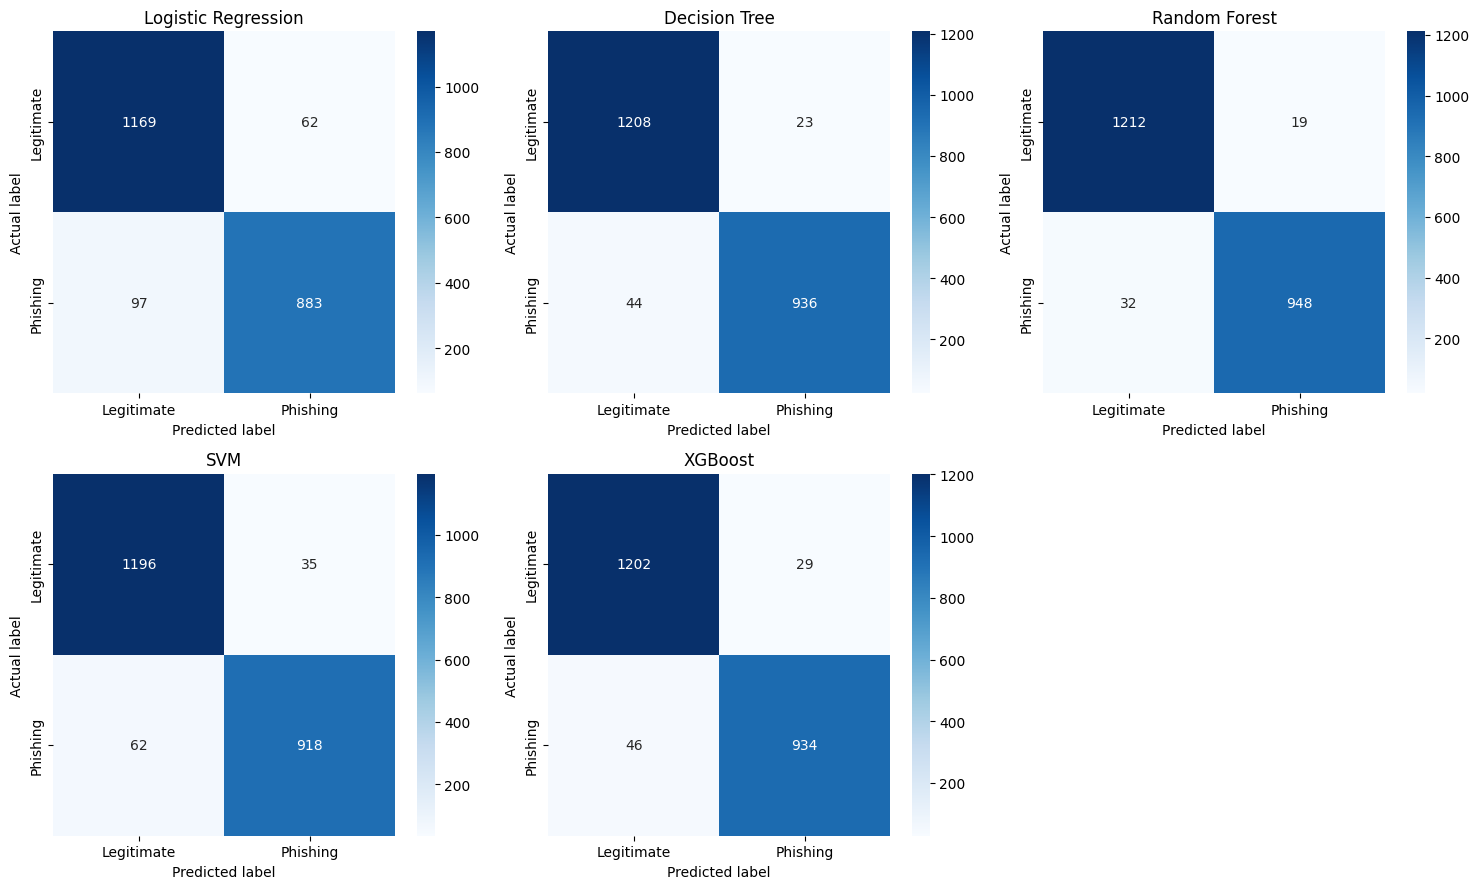

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for index, (model_name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    matrix = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[index],
        xticklabels=["Legitimate", "Phishing"],
        yticklabels=["Legitimate", "Phishing"]
    )

    axes[index].set_title(model_name)
    axes[index].set_xlabel("Predicted label")
    axes[index].set_ylabel("Actual label")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

In [27]:
results_df.to_csv("baseline_model_results.csv", index=False)

In [28]:
processed_data = X.copy()
processed_data["Result"] = y
processed_data.to_csv("processed_phishing_data.csv", index=False)

In [29]:
rf_model = models["Random Forest"]

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance_df.head(15))

                        Feature  Importance
7                SSLfinal_State    0.324522
13                URL_of_Anchor    0.249173
25                  web_traffic    0.074073
6             having_Sub_Domain    0.063353
14                Links_in_tags    0.042460
5                 Prefix_Suffix    0.040485
15                          SFH    0.020736
28       Links_pointing_to_page    0.018397
12                  Request_URL    0.018154
8   Domain_registeration_length    0.016411
23                age_of_domain    0.015664
0             having_IP_Address    0.012651
27                 Google_Index    0.012541
24                    DNSRecord    0.012149
26                    Page_Rank    0.011858


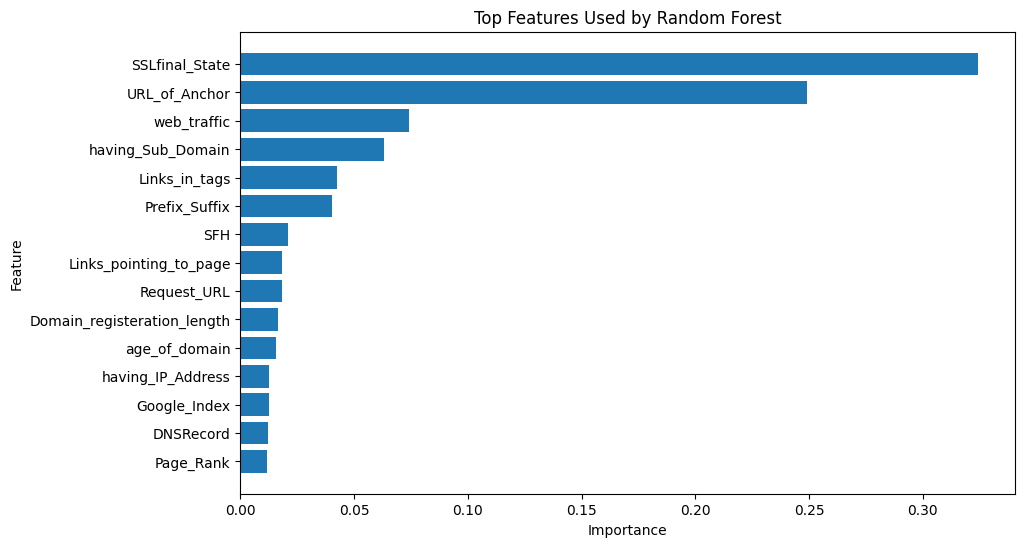

In [30]:
top_features = importance_df.head(15).sort_values("Importance")

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Features Used by Random Forest")
plt.show()

In [31]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Precision Mean": scores["test_precision"].mean(),
        "Recall Mean": scores["test_recall"].mean(),
        "F1 Mean": scores["test_f1"].mean(),
        "ROC-AUC Mean": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean
0,Logistic Regression,0.927182,0.004946,0.929154,0.904656,0.916687,0.978758
1,Decision Tree,0.963003,0.005594,0.970465,0.945281,0.957673,0.974946
2,Random Forest,0.970149,0.002699,0.974306,0.957940,0.966011,0.995732
3,SVM,0.951877,0.002782,0.960258,0.929971,0.944826,0.988357
4,XGBoost,0.958842,0.003094,0.962178,0.944263,0.953098,0.994084


In [32]:
cv_results_df.to_csv("stage3_cross_validation_results.csv", index=False)

In [33]:
X = data.drop("Result", axis=1).copy()
y = data["Result"].copy()

In [34]:
print("Original rows in data:", len(data))
print("Original feature rows:", len(X))
print("Original columns:", X.shape[1])

Original rows in data: 11055
Original feature rows: 11055
Original columns: 30


In [35]:
print("Duplicate complete rows:", data.duplicated().sum())
print("Duplicate feature rows:", X.duplicated().sum())

Duplicate complete rows: 5206
Duplicate feature rows: 5270


In [36]:
duplicate_labels = data.groupby(
    list(X.columns)
)["Result"].nunique()

conflicting_duplicates = (duplicate_labels > 1).sum()

print("Feature patterns with conflicting labels:",
      conflicting_duplicates)

Feature patterns with conflicting labels: 64


In [37]:
clean_data = data.drop_duplicates().reset_index(drop=True)

print("Original rows:", len(data))
print("Rows after duplicate removal:", len(clean_data))
print("Rows removed:", len(data) - len(clean_data))

Original rows: 11055
Rows after duplicate removal: 5849
Rows removed: 5206


In [38]:
percentage_removed = (
    (len(data) - len(clean_data)) / len(data)
) * 100

print(f"Percentage removed: {percentage_removed:.2f}%")

Percentage removed: 47.09%


In [39]:
X_clean = clean_data.drop("Result", axis=1).copy()
y_clean = clean_data["Result"].copy()

for column in X_clean.columns:
    X_clean[column] = X_clean[column].apply(
        lambda value: value.decode("utf-8")
        if isinstance(value, bytes)
        else value
    )

X_clean = X_clean.apply(pd.to_numeric)

y_clean = y_clean.apply(
    lambda value: value.decode("utf-8")
    if isinstance(value, bytes)
    else value
)

y_clean = pd.to_numeric(y_clean)

print(X_clean.shape)
print(y_clean.shape)
print(y_clean.value_counts())

(5849, 30)
(5849,)
Result
1    3019
0    2830
Name: count, dtype: int64


In [40]:
from sklearn.model_selection import train_test_split

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_clean,
    test_size=0.20,
    random_state=42,
    stratify=y_clean
)

In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

original_results = []

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    y_probability = model.predict_proba(X_test)[:, 1]

    original_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_probability)
    })

original_results_df = pd.DataFrame(original_results)
original_results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.928087,0.934392,0.901020,0.917403,0.978503
1,Decision Tree,0.969697,0.976017,0.955102,0.965446,0.976431
2,Random Forest,0.976934,0.980352,0.967347,0.973806,0.996385
3,SVM,0.956128,0.963274,0.936735,0.949819,0.989042
4,XGBoost,0.966079,0.969886,0.953061,0.961400,0.994879


In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

clean_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            probability=True,
            random_state=42
        ))
    ]),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

In [43]:
for model_name, model in clean_models.items():
    print(f"Training cleaned-data model: {model_name}")
    model.fit(X_train_clean, y_train_clean)

Training cleaned-data model: Logistic Regression
Training cleaned-data model: Decision Tree
Training cleaned-data model: Random Forest
Training cleaned-data model: SVM
Training cleaned-data model: XGBoost


In [44]:
clean_results = []

for model_name, model in clean_models.items():
    y_pred = model.predict(X_test_clean)
    y_probability = model.predict_proba(X_test_clean)[:, 1]

    clean_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test_clean,
            y_pred
        ),
        "Precision": precision_score(
            y_test_clean,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_clean,
            y_pred,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_test_clean,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test_clean,
            y_probability
        )
    })

clean_results_df = pd.DataFrame(clean_results)
clean_results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.917949,0.924749,0.915563,0.920133,0.977582
1,Decision Tree,0.911111,0.926621,0.899007,0.912605,0.917777
2,Random Forest,0.940171,0.957192,0.925497,0.941077,0.985191
3,SVM,0.935897,0.947547,0.927152,0.937238,0.984155
4,XGBoost,0.952137,0.961279,0.945364,0.953255,0.992564


In [45]:
original_results_df["Dataset version"] = "Original"
clean_results_df["Dataset version"] = "Duplicates removed"

comparison_df = pd.concat(
    [original_results_df, clean_results_df],
    ignore_index=True
)

comparison_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Dataset version
0,Logistic Regression,0.928087,0.934392,0.901020,0.917403,0.978503,Original
1,Decision Tree,0.969697,0.976017,0.955102,0.965446,0.976431,Original
2,Random Forest,0.976934,0.980352,0.967347,0.973806,0.996385,Original
3,SVM,0.956128,0.963274,0.936735,0.949819,0.989042,Original
4,XGBoost,0.966079,0.969886,0.953061,0.961400,0.994879,Original
5,Logistic Regression,0.917949,0.924749,0.915563,0.920133,0.977582,Duplicates removed
6,Decision Tree,0.911111,0.926621,0.899007,0.912605,0.917777,Duplicates removed
7,Random Forest,0.940171,0.957192,0.925497,0.941077,0.985191,Duplicates removed
8,SVM,0.935897,0.947547,0.927152,0.937238,0.984155,Duplicates removed
9,XGBoost,0.952137,0.961279,0.945364,0.953255,0.992564,Duplicates removed


In [46]:
comparison_table = original_results_df.merge(
    clean_results_df,
    on="Model",
    suffixes=("_original", "_cleaned")
)

comparison_table

,Model,Accuracy_original,Precision_original,Recall_original,F1-score_original,ROC-AUC_original,Dataset version_original,Accuracy_cleaned,Precision_cleaned,Recall_cleaned,F1-score_cleaned,ROC-AUC_cleaned,Dataset version_cleaned
0,Logistic Regression,0.928087,0.934392,0.901020,0.917403,0.978503,Original,0.917949,0.924749,0.915563,0.920133,0.977582,Duplicates removed
1,Decision Tree,0.969697,0.976017,0.955102,0.965446,0.976431,Original,0.911111,0.926621,0.899007,0.912605,0.917777,Duplicates removed
2,Random Forest,0.976934,0.980352,0.967347,0.973806,0.996385,Original,0.940171,0.957192,0.925497,0.941077,0.985191,Duplicates removed
3,SVM,0.956128,0.963274,0.936735,0.949819,0.989042,Original,0.935897,0.947547,0.927152,0.937238,0.984155,Duplicates removed
4,XGBoost,0.966079,0.969886,0.953061,0.961400,0.994879,Original,0.952137,0.961279,0.945364,0.953255,0.992564,Duplicates removed


In [47]:
comparison_table["F1_change"] = (
    comparison_table["F1-score_cleaned"]
    - comparison_table["F1-score_original"]
)

comparison_table["Recall_change"] = (
    comparison_table["Recall_cleaned"]
    - comparison_table["Recall_original"]
)

comparison_table["Accuracy_change"] = (
    comparison_table["Accuracy_cleaned"]
    - comparison_table["Accuracy_original"]
)

comparison_table

,Model,Accuracy_original,Precision_original,Recall_original,F1-score_original,ROC-AUC_original,Dataset version_original,Accuracy_cleaned,Precision_cleaned,Recall_cleaned,F1-score_cleaned,ROC-AUC_cleaned,Dataset version_cleaned,F1_change,Recall_change,Accuracy_change
0,Logistic Regression,0.928087,0.934392,0.901020,0.917403,0.978503,Original,0.917949,0.924749,0.915563,0.920133,0.977582,Duplicates removed,0.002731,0.014543,-0.010138
1,Decision Tree,0.969697,0.976017,0.955102,0.965446,0.976431,Original,0.911111,0.926621,0.899007,0.912605,0.917777,Duplicates removed,-0.052841,-0.056095,-0.058586
2,Random Forest,0.976934,0.980352,0.967347,0.973806,0.996385,Original,0.940171,0.957192,0.925497,0.941077,0.985191,Duplicates removed,-0.032728,-0.041850,-0.036763
3,SVM,0.956128,0.963274,0.936735,0.949819,0.989042,Original,0.935897,0.947547,0.927152,0.937238,0.984155,Duplicates removed,-0.012580,-0.009582,-0.020231
4,XGBoost,0.966079,0.969886,0.953061,0.961400,0.994879,Original,0.952137,0.961279,0.945364,0.953255,0.992564,Duplicates removed,-0.008144,-0.007697,-0.013942


In [48]:
comparison_table.to_csv(
    "before_after_duplicate_removal.csv",
    index=False
)

In [49]:
print("Original rows:", len(data))
print("Duplicate rows:", data.duplicated().sum())
print("Cleaned rows:", len(clean_data))
print("Rows removed:", len(data) - len(clean_data))

Original rows: 11055
Duplicate rows: 5206
Cleaned rows: 5849
Rows removed: 5206


In [50]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for model_name, model in clean_models.items():
    scores = cross_validate(
        model,
        X_clean,
        y_clean,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Precision Mean": scores["test_precision"].mean(),
        "Recall Mean": scores["test_recall"].mean(),
        "F1 Mean": scores["test_f1"].mean(),
        "ROC-AUC Mean": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean
0,Logistic Regression,0.918962,0.005984,0.926049,0.916202,0.921082,0.975788
1,Decision Tree,0.924603,0.006313,0.936715,0.915863,0.926119,0.929522
2,Random Forest,0.948880,0.003947,0.955784,0.944683,0.950187,0.988697
3,SVM,0.941187,0.001121,0.954494,0.930441,0.942301,0.983771
4,XGBoost,0.950932,0.005984,0.958155,0.946340,0.952194,0.991885


In [51]:
X = data.drop("Result", axis=1).copy()
y = data["Result"].copy()

for column in X.columns:
    X[column] = X[column].apply(lambda v: v.decode("utf-8") if isinstance(v, bytes) else v)
X = X.apply(pd.to_numeric)

y = y.apply(lambda v: v.decode("utf-8") if isinstance(v, bytes) else v)
y = pd.to_numeric(y)

print("X dtypes check:", X.dtypes.unique())
print("y dtypes check:", y.dtype)

# Now remove duplicates
print("Before duplicate removal:")
print("Original rows in data:", data.shape[0])

processed_data = X.copy()
processed_data["Result"] = y

full_dupes = processed_data.duplicated().sum()
feature_dupes = X.duplicated().sum()

conflicting = X.assign(Result=y).groupby(list(X.columns))["Result"].nunique()
conflicting_patterns = (conflicting > 1).sum()

print("Original feature rows:", X.shape[0])
print("Original columns:", X.shape[1])
print("Duplicate complete rows:", full_dupes)
print("Duplicate feature rows:", feature_dupes)
print("Feature patterns with conflicting labels:", conflicting_patterns)

dedup_data = processed_data.drop_duplicates().reset_index(drop=True)

print("Original rows:", processed_data.shape[0])
print("Rows after duplicate removal:", dedup_data.shape[0])
print("Rows removed:", processed_data.shape[0] - dedup_data.shape[0])
print("Percentage removed:", round(100 * (1 - dedup_data.shape[0] / processed_data.shape[0]), 2), "%")

X_clean = dedup_data.drop("Result", axis=1)
y_clean = dedup_data["Result"]

X dtypes check: [dtype('int64')]
y dtypes check: int64
Before duplicate removal:
Original rows in data: 11055
Original feature rows: 11055
Original columns: 30
Duplicate complete rows: 5206
Duplicate feature rows: 5270
Feature patterns with conflicting labels: 64
Original rows: 11055
Rows after duplicate removal: 5849
Rows removed: 5206
Percentage removed: 47.09 %


In [52]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_clean, test_size=0.20, random_state=42, stratify=y_clean
)

clean_models = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=2000))]),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "SVM": Pipeline([("scaler", StandardScaler()), ("model", SVC(probability=True, random_state=42))]),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        objective="binary:logistic", eval_metric="logloss",
        random_state=42, n_jobs=-1
    ),
}

clean_results = []
for name, model in clean_models.items():
    model.fit(X_train_c, y_train_c)
    pred = model.predict(X_test_c)
    prob = model.predict_proba(X_test_c)[:, 1]
    clean_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_c, pred),
        "Precision": precision_score(y_test_c, pred),
        "Recall": recall_score(y_test_c, pred),
        "F1-score": f1_score(y_test_c, pred),
        "ROC-AUC": roc_auc_score(y_test_c, prob),
    })

clean_results_df = pd.DataFrame(clean_results)
clean_results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.917949,0.924749,0.915563,0.920133,0.977582
1,Decision Tree,0.911111,0.926621,0.899007,0.912605,0.917777
2,Random Forest,0.940171,0.957192,0.925497,0.941077,0.985191
3,SVM,0.935897,0.947547,0.927152,0.937238,0.984155
4,XGBoost,0.952137,0.961279,0.945364,0.953255,0.992564


In [53]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

X_arr = X_clean.values
y_arr = y_clean.values

def make_models():
    return {
        "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=2000))]),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
        "SVM": Pipeline([("scaler", StandardScaler()), ("model", SVC(probability=True, random_state=42))]),
        "XGBoost": XGBClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            objective="binary:logistic", eval_metric="logloss",
            random_state=42, n_jobs=-1
        ),
    }

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = {name: {"acc": [], "prec": [], "rec": [], "f1": [], "auc": []} for name in make_models()}

for train_idx, test_idx in skf.split(X_arr, y_arr):
    X_tr, X_te = X_arr[train_idx], X_arr[test_idx]
    y_tr, y_te = y_arr[train_idx], y_arr[test_idx]

    for name, model in make_models().items():
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        prob = model.predict_proba(X_te)[:, 1]
        cv_scores[name]["acc"].append(accuracy_score(y_te, pred))
        cv_scores[name]["prec"].append(precision_score(y_te, pred))
        cv_scores[name]["rec"].append(recall_score(y_te, pred))
        cv_scores[name]["f1"].append(f1_score(y_te, pred))
        cv_scores[name]["auc"].append(roc_auc_score(y_te, prob))

cv_rows = []
for name, s in cv_scores.items():
    cv_rows.append({
        "Model": name,
        "Accuracy Mean": np.mean(s["acc"]),
        "Accuracy Std": np.std(s["acc"]),
        "Precision Mean": np.mean(s["prec"]),
        "Recall Mean": np.mean(s["rec"]),
        "F1 Mean": np.mean(s["f1"]),
        "ROC-AUC Mean": np.mean(s["auc"]),
    })

cv_results_df = pd.DataFrame(cv_rows)
cv_results_df

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean
0,Logistic Regression,0.918962,0.005984,0.926049,0.916202,0.921082,0.975788
1,Decision Tree,0.924603,0.006313,0.936715,0.915863,0.926119,0.929522
2,Random Forest,0.948880,0.003947,0.955784,0.944683,0.950187,0.988697
3,SVM,0.941187,0.001121,0.954494,0.930441,0.942301,0.983774
4,XGBoost,0.950248,0.005495,0.958728,0.944352,0.951460,0.991876


In [54]:
phiusiil = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")
print(phiusiil.shape)

(235795, 56)


In [55]:
uci_common = pd.DataFrame({
    "has_ip":        (X_clean["having_IP_Address"] == 1).astype(int),
    "is_https":      (X_clean["HTTPS_token"] == 1).astype(int),
    "has_subdomain": (X_clean["having_Sub_Domain"] == 1).astype(int),
    "has_favicon":   (X_clean["Favicon"] == 1).astype(int),
    "has_popup":     (X_clean["popUpWidnow"] == 1).astype(int),
    "has_iframe":    (X_clean["Iframe"] == 1).astype(int),
    "has_redirect":  (X_clean["Redirect"] == 1).astype(int),
})
uci_common_y = y_clean

phiusiil_common = pd.DataFrame({
    "has_ip":        phiusiil["IsDomainIP"].astype(int),
    "is_https":      phiusiil["IsHTTPS"].astype(int),
    "has_subdomain": (phiusiil["NoOfSubDomain"] > 0).astype(int),
    "has_favicon":   phiusiil["HasFavicon"].astype(int),
    "has_popup":     (phiusiil["NoOfPopup"] > 0).astype(int),
    "has_iframe":    (phiusiil["NoOfiFrame"] > 0).astype(int),
    "has_redirect":  (phiusiil["NoOfURLRedirect"] > 0).astype(int),
})
phiusiil_common_y = phiusiil["label"]  
phiusiil_common_y = 1 - phiusiil_common_y  

print("uci_common:", uci_common.shape, " phiusiil_common:", phiusiil_common.shape)

uci_common: (5849, 7)  phiusiil_common: (235795, 7)


In [56]:
uci_common["has_email_submit"] = (X_clean["Submitting_to_email"] == 1).astype(int)
phiusiil_common["has_email_submit"] = phiusiil["HasExternalFormSubmit"].astype(int)  # closest available proxy

uci_common["short_url_suspicious"] = (X_clean["URL_Length"] == 1).astype(int)  # UCI already bins this
phiusiil_common["short_url_suspicious"] = (phiusiil["URLLength"] > 75).astype(int)  # threshold UCI's own paper uses

In [57]:
uci_common = uci_common.drop(columns=["has_email_submit"])
phiusiil_common = phiusiil_common.drop(columns=["has_email_submit"])

print(uci_common.columns.tolist())
print(phiusiil_common.columns.tolist())

['has_ip', 'is_https', 'has_subdomain', 'has_favicon', 'has_popup', 'has_iframe', 'has_redirect', 'short_url_suspicious']
['has_ip', 'is_https', 'has_subdomain', 'has_favicon', 'has_popup', 'has_iframe', 'has_redirect', 'short_url_suspicious']


In [58]:
model_trainUCI = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective="binary:logistic", eval_metric="logloss",
    random_state=42, n_jobs=-1
)
model_trainUCI.fit(uci_common, uci_common_y)

preds_testPHI = model_trainUCI.predict(phiusiil_common)
probs_testPHI = model_trainUCI.predict_proba(phiusiil_common)[:, 1]

print("TRAIN=UCI, TEST=PhiUSIIL")
print("Train rows:", uci_common.shape[0], "  Test rows:", phiusiil_common.shape[0])
print("Accuracy :", accuracy_score(phiusiil_common_y, preds_testPHI))
print("Precision:", precision_score(phiusiil_common_y, preds_testPHI))
print("Recall   :", recall_score(phiusiil_common_y, preds_testPHI))
print("F1-score :", f1_score(phiusiil_common_y, preds_testPHI))
print("ROC-AUC  :", roc_auc_score(phiusiil_common_y, probs_testPHI))

TRAIN=UCI, TEST=PhiUSIIL
Train rows: 5849   Test rows: 235795
Accuracy : 0.7751648677876969
Precision: 0.8173499655702103
Recall   : 0.6114517806726435
F1-score : 0.6995653430503057
ROC-AUC  : 0.7101262609313438


In [59]:
model_trainPHI = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective="binary:logistic", eval_metric="logloss",
    random_state=42, n_jobs=-1
)
model_trainPHI.fit(phiusiil_common, phiusiil_common_y)

preds_testUCI = model_trainPHI.predict(uci_common)
probs_testUCI = model_trainPHI.predict_proba(uci_common)[:, 1]

print("TRAIN=PhiUSIIL, TEST=UCI")
print("Train rows:", phiusiil_common.shape[0], "  Test rows:", uci_common.shape[0])
print("Accuracy :", accuracy_score(uci_common_y, preds_testUCI))
print("Precision:", precision_score(uci_common_y, preds_testUCI))
print("Recall   :", recall_score(uci_common_y, preds_testUCI))
print("F1-score :", f1_score(uci_common_y, preds_testUCI))
print("ROC-AUC  :", roc_auc_score(uci_common_y, probs_testUCI))

TRAIN=PhiUSIIL, TEST=UCI
Train rows: 235795   Test rows: 5849
Accuracy : 0.612412378184305
Precision: 0.5831858407079646
Recall   : 0.8731368002649884
F1-score : 0.6992969889905823
ROC-AUC  : 0.5881151997303298


                        Feature  Importance
7                SSLfinal_State    0.349101
13                URL_of_Anchor    0.177089
5                 Prefix_Suffix    0.073635
15                          SFH    0.035487
14                Links_in_tags    0.034500
25                  web_traffic    0.028319
6             having_Sub_Domain    0.023613
2            Shortining_Service    0.022555
27                 Google_Index    0.018447
8   Domain_registeration_length    0.015368
12                  Request_URL    0.015211
21                  popUpWidnow    0.014977
0             having_IP_Address    0.014795
4      double_slash_redirecting    0.013870
28       Links_pointing_to_page    0.013313


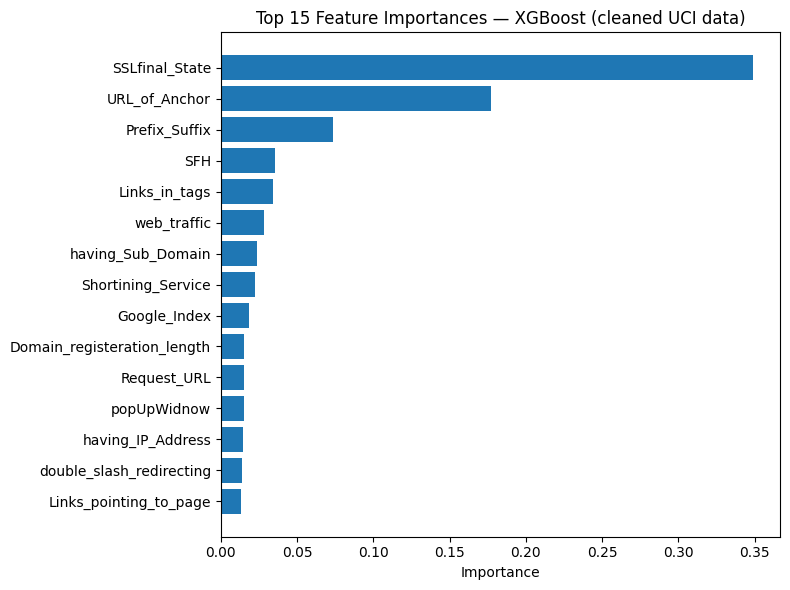

In [60]:
import matplotlib.pyplot as plt

xgb_full = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective="binary:logistic", eval_metric="logloss",
    random_state=42, n_jobs=-1
)
xgb_full.fit(X_train_c, y_train_c)

importance_df = pd.DataFrame({
    "Feature": X_train_c.columns,
    "Importance": xgb_full.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance_df.head(15))

plt.figure(figsize=(8, 6))
plt.barh(importance_df["Feature"].head(15)[::-1], importance_df["Importance"].head(15)[::-1])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances — XGBoost (cleaned UCI data)")
plt.tight_layout()
plt.show()

In [61]:
print(X_clean.groupby("SSLfinal_State")["Result"].mean() if "Result" in X_clean.columns else dedup_data.groupby("SSLfinal_State")["Result"].value_counts(normalize=True))
print("\n")
print(dedup_data.groupby("SSLfinal_State")["Result"].mean())

SSLfinal_State  Result
-1              1         0.875940
                0         0.124060
 0              1         0.990291
                0         0.009709
 1              0         0.853000
                1         0.147000
Name: proportion, dtype: float64


SSLfinal_State
-1    0.875940
 0    0.990291
 1    0.147000
Name: Result, dtype: float64


In [62]:
non_controllable = [
    "age_of_domain", "web_traffic", "Page_Rank",
    "Google_Index", "Links_pointing_to_page", "Statistical_report"
]

controllable = [c for c in X_train_c.columns if c not in non_controllable]

print(f"Controllable features ({len(controllable)}):")
print(controllable)
print(f"\nNon-controllable features ({len(non_controllable)}):")
print(non_controllable)

Controllable features (24):
['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'DNSRecord']

Non-controllable features (6):
['age_of_domain', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report']


In [63]:
import numpy as np

phishing_mask = (y_test_c == 1) & (xgb_full.predict(X_test_c) == 1)
X_phish = X_test_c[phishing_mask].copy()
print(f"Testing evasion on {len(X_phish)} correctly-detected phishing samples")

flip_results = []
for feat in controllable:
    legit_value = 1 if X_train_c[feat].max() == 1 else X_train_c[feat].max()
    X_perturbed = X_phish.copy()
    X_perturbed[feat] = legit_value

    new_preds = xgb_full.predict(X_perturbed)
    evasion_rate = (new_preds == 0).mean()
    flip_results.append({"Feature": feat, "Evasion Rate": evasion_rate})

flip_df = pd.DataFrame(flip_results).sort_values("Evasion Rate", ascending=False)
print(flip_df.head(15))

Testing evasion on 571 correctly-detected phishing samples
                        Feature  Evasion Rate
5                 Prefix_Suffix      0.388792
13                URL_of_Anchor      0.189142
7                SSLfinal_State      0.150613
15                          SFH      0.092820
6             having_Sub_Domain      0.050788
0             having_IP_Address      0.042032
14                Links_in_tags      0.024518
1                    URL_Length      0.017513
23                    DNSRecord      0.010508
12                  Request_URL      0.010508
8   Domain_registeration_length      0.001751
2            Shortining_Service      0.000000
4      double_slash_redirecting      0.000000
3              having_At_Symbol      0.000000
9                       Favicon      0.000000


In [64]:
important_controllable = [f for f in importance_df["Feature"] if f in controllable]

costs = []
for idx in X_phish.index:
    row = X_phish.loc[[idx]].copy()
    n_flipped = 0
    for feat in important_controllable:
        legit_value = 1 if X_train_c[feat].max() == 1 else X_train_c[feat].max()
        row[feat] = legit_value
        n_flipped += 1
        if xgb_full.predict(row)[0] == 0:
            break
    costs.append(n_flipped)

costs = np.array(costs)
print("Mean features needed to evade:", costs.mean())
print("Median features needed to evade:", np.median(costs))
print("% evadable by changing just 1 feature:", (costs == 1).mean() * 100)
print("% evadable by changing 3 or fewer features:", (costs <= 3).mean() * 100)
print("% never evaded within all controllable features:", (costs == len(important_controllable)).mean() * 100)

Mean features needed to evade: 1.9702276707530648
Median features needed to evade: 2.0
% evadable by changing just 1 feature: 15.061295971978982
% evadable by changing 3 or fewer features: 100.0
% never evaded within all controllable features: 0.0


In [65]:
np.random.seed(1)
for trial in range(3):
    sample_idx = np.random.choice(X_phish.index, size=len(X_phish), replace=True)
    X_boot = X_phish.loc[sample_idx]

    boot_results = []
    for feat in controllable:
        legit_value = 1 if X_train_c[feat].max() == 1 else X_train_c[feat].max()
        X_perturbed = X_boot.copy()
        X_perturbed[feat] = legit_value
        new_preds = xgb_full.predict(X_perturbed)
        boot_results.append({"Feature": feat, "Evasion Rate": (new_preds == 0).mean()})

    boot_df = pd.DataFrame(boot_results).sort_values("Evasion Rate", ascending=False)
    print(f"--- Trial {trial+1} ---")
    print(boot_df.head(3))

--- Trial 1 ---
           Feature  Evasion Rate
5    Prefix_Suffix      0.374781
13   URL_of_Anchor      0.194396
7   SSLfinal_State      0.143608
--- Trial 2 ---
           Feature  Evasion Rate
5    Prefix_Suffix      0.364273
13   URL_of_Anchor      0.197898
7   SSLfinal_State      0.147110
--- Trial 3 ---
           Feature  Evasion Rate
5    Prefix_Suffix      0.394046
13   URL_of_Anchor      0.217163
7   SSLfinal_State      0.134851


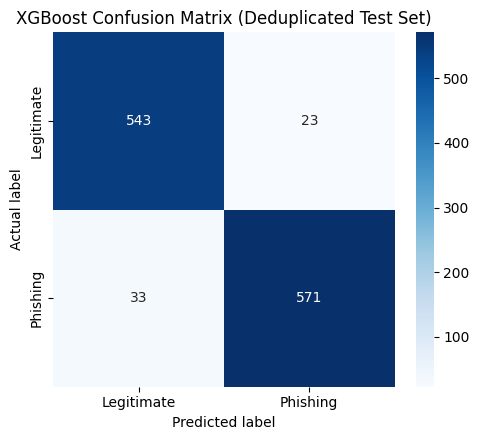

In [71]:
# Confusion matrix for XGBoost, on the deduplicated test set (X_test_c/y_test_c)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

pred_xgb = clean_models["XGBoost"].predict(X_test_c)
cm = confusion_matrix(y_test_c, pred_xgb)

plt.figure(figsize=(5,4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legitimate","Phishing"], yticklabels=["Legitimate","Phishing"])
plt.xlabel("Predicted label"); plt.ylabel("Actual label")
plt.title("XGBoost Confusion Matrix (Deduplicated Test Set)")
plt.tight_layout()
plt.savefig("xgb_confusion_matrix.png", dpi=200)
plt.show()

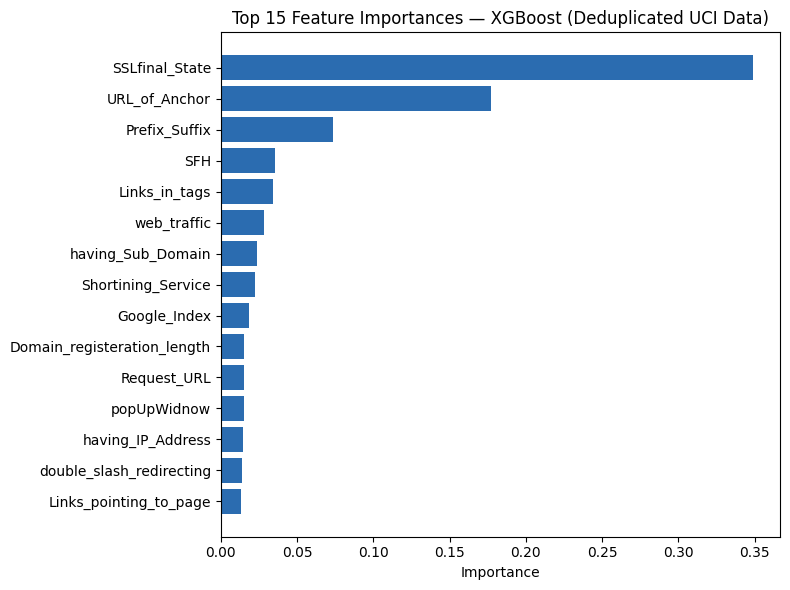

In [72]:
# Feature importance — reuse your existing importance_df from Section 4, just save it
plt.figure(figsize=(8,6))
top15 = importance_df.head(15).sort_values("Importance")
plt.barh(top15["Feature"], top15["Importance"], color="#2b6cb0")
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances — XGBoost (Deduplicated UCI Data)")
plt.tight_layout()
plt.savefig("xgb_feature_importance.png", dpi=200)
plt.show()

In [66]:
import pandas as pd

uci = pd.read_csv("processed_phishing_data.csv")
feature_cols = [col for col in uci.columns if col != "Result"]

pattern_summary = (
    uci.groupby(feature_cols, dropna=False)["Result"]
       .agg(n_rows="size", n_labels="nunique")
       .reset_index()
)

conflicting_patterns = pattern_summary[
    pattern_summary["n_labels"] > 1
][feature_cols]

print("Original rows:", len(uci))
print("Unique feature + label rows:", len(uci.drop_duplicates()))
print("Unique feature patterns:", len(pattern_summary))
print("Conflicting feature patterns:", len(conflicting_patterns))

Original rows: 11055
Unique feature + label rows: 5849
Unique feature patterns: 5785
Conflicting feature patterns: 64


In [67]:
conflict_index = pd.MultiIndex.from_frame(conflicting_patterns)
row_index = pd.MultiIndex.from_frame(uci[feature_cols])

uci_unambiguous = uci.loc[
    ~row_index.isin(conflict_index)
].drop_duplicates(subset=feature_cols).reset_index(drop=True)

print("Unambiguous feature patterns:", len(uci_unambiguous))
print(uci_unambiguous["Result"].value_counts())

Unambiguous feature patterns: 5721
Result
1    2955
0    2766
Name: count, dtype: int64


In [68]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

uci_old_policy = (
    uci.drop_duplicates()
       .reset_index(drop=True)
)

datasets = {
    "Original deduplication (5,849 rows)": uci_old_policy,
    "Remove conflicting patterns (5,721 rows)": uci_unambiguous
}

# Use the SAME model specifications and fold settings for both policies.
# 'cleanmodels' is defined in your existing notebook.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

records = []

for policy_name, dataset in datasets.items():
    X_policy = dataset[feature_cols]
    y_policy = dataset["Result"]

    for fold_number, (train_idx, test_idx) in enumerate(
        cv.split(X_policy, y_policy), start=1
    ):
        X_train = X_policy.iloc[train_idx]
        X_test = X_policy.iloc[test_idx]
        y_train = y_policy.iloc[train_idx]
        y_test = y_policy.iloc[test_idx]

        for model_name, model_template in clean_models.items():
            model = clone(model_template)
            model.fit(X_train, y_train)

            predictions = model.predict(X_test)
            probabilities = model.predict_proba(X_test)[:, 1]

            records.append({
                "Policy": policy_name,
                "Model": model_name,
                "Fold": fold_number,
                "Accuracy": accuracy_score(y_test, predictions),
                "Precision": precision_score(
                    y_test, predictions, zero_division=0
                ),
                "Recall": recall_score(
                    y_test, predictions, zero_division=0
                ),
                "F1": f1_score(
                    y_test, predictions, zero_division=0
                ),
                "ROC-AUC": roc_auc_score(y_test, probabilities)
            })

policy_fold_results = pd.DataFrame(records)

policy_summary = (
    policy_fold_results
    .groupby(["Policy", "Model"])
    .agg(
        Accuracy_mean=("Accuracy", "mean"),
        Accuracy_std=("Accuracy", "std"),
        F1_mean=("F1", "mean"),
        F1_std=("F1", "std"),
        ROC_AUC_mean=("ROC-AUC", "mean"),
        ROC_AUC_std=("ROC-AUC", "std")
    )
    .reset_index()
)

print(policy_summary.round(4).to_string(index=False))

                                  Policy               Model  Accuracy_mean  Accuracy_std  F1_mean  F1_std  ROC_AUC_mean  ROC_AUC_std
     Original deduplication (5,849 rows)       Decision Tree         0.9246        0.0071   0.9261  0.0072        0.9295       0.0064
     Original deduplication (5,849 rows) Logistic Regression         0.9190        0.0067   0.9211  0.0065        0.9758       0.0021
     Original deduplication (5,849 rows)       Random Forest         0.9489        0.0044   0.9502  0.0044        0.9887       0.0024
     Original deduplication (5,849 rows)                 SVM         0.9412        0.0013   0.9423  0.0012        0.9838       0.0025
     Original deduplication (5,849 rows)             XGBoost         0.9502        0.0061   0.9515  0.0058        0.9919       0.0016
Remove conflicting patterns (5,721 rows)       Decision Tree         0.9455        0.0050   0.9471  0.0049        0.9455       0.0050
Remove conflicting patterns (5,721 rows) Logistic Regression  

In [69]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score
from xgboost import XGBClassifier

uci_control = (
    pd.read_csv("processed_phishing_data.csv")
      .drop_duplicates()
      .reset_index(drop=True)
)

y_control = uci_control["Result"].astype(int)
X_full = uci_control.drop(columns="Result")

# Reproduce the UCI-side mapping in your existing transfer notebook.
X_eight = pd.DataFrame({
    "has_ip": (X_full["having_IP_Address"] == 1).astype(int),
    "is_https": (X_full["HTTPS_token"] == 1).astype(int),
    "has_subdomain": (X_full["having_Sub_Domain"] == 1).astype(int),
    "has_favicon": (X_full["Favicon"] == 1).astype(int),
    "has_popup": (X_full["popUpWidnow"] == 1).astype(int),
    "has_iframe": (X_full["Iframe"] == 1).astype(int),
    "has_redirect": (X_full["Redirect"] == 1).astype(int),
    "short_url_suspicious": (X_full["URL_Length"] == 1).astype(int)
})

def make_control_model():
    return XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
control_rows = []

for fold, (train_idx, test_idx) in enumerate(
    cv.split(X_full, y_control), start=1
):
    for name, X_features in [
        ("UCI, all 30 features", X_full),
        ("UCI, existing mapped 8 features", X_eight)
    ]:
        model = make_control_model()
        model.fit(
            X_features.iloc[train_idx],
            y_control.iloc[train_idx]
        )
        scores = model.predict_proba(
            X_features.iloc[test_idx]
        )[:, 1]
        predictions = (scores >= 0.5).astype(int)

        control_rows.append({
            "Fold": fold,
            "Representation": name,
            "Accuracy": accuracy_score(
                y_control.iloc[test_idx], predictions
            ),
            "ROC_AUC": roc_auc_score(
                y_control.iloc[test_idx], scores
            )
        })

control_folds = pd.DataFrame(control_rows)

print(
    control_folds.groupby("Representation")
    .agg(
        Accuracy_mean=("Accuracy", "mean"),
        Accuracy_sd=("Accuracy", "std"),
        ROC_AUC_mean=("ROC_AUC", "mean"),
        ROC_AUC_sd=("ROC_AUC", "std")
    )
    .round(4)
    .to_string()
)

                                 Accuracy_mean  Accuracy_sd  ROC_AUC_mean  ROC_AUC_sd
Representation                                                                       
UCI, all 30 features                    0.9502       0.0061        0.9919      0.0016
UCI, existing mapped 8 features         0.7063       0.0050        0.7613      0.0117


In [70]:
print("UCI HTTPS_token values and phishing rates:")
print(
    uci_control.groupby("HTTPS_token")["Result"]
    .agg(count="size", phishing_rate="mean")
)

print("\nUCI URL_Length values and phishing rates:")
print(
    uci_control.groupby("URL_Length")["Result"]
    .agg(count="size", phishing_rate="mean")
)

print("\nPhiUSIIL IsHTTPS values and phishing rates:")
phi_check = phiusiil.copy()
phi_check["phishing_label"] = 1 - phi_check["label"]
print(
    phi_check.groupby("IsHTTPS")["phishing_label"]
    .agg(count="size", phishing_rate="mean")
)

print("\nPhiUSIIL URLLength <= 75 and > 75:")
phi_check["over_75"] = (phi_check["URLLength"] > 75).astype(int)
print(
    phi_check.groupby("over_75")["phishing_label"]
    .agg(count="size", phishing_rate="mean")
)

UCI HTTPS_token values and phishing rates:
             count  phishing_rate
HTTPS_token                      
-1            1013       0.460020
 1            4836       0.527916

UCI URL_Length values and phishing rates:
            count  phishing_rate
URL_Length                      
-1           4678       0.529286
 0             96       0.614583
 1           1075       0.450233

PhiUSIIL IsHTTPS values and phishing rates:
          count  phishing_rate
IsHTTPS                       
0         51256        1.00000
1        184539        0.26926

PhiUSIIL URLLength <= 75 and > 75:
          count  phishing_rate
over_75                       
0        224640       0.399706
1         11155       1.000000


In [73]:
mapping_audit = pd.DataFrame([
    {
        "common_name": "has_ip",
        "uci_feature": "having_IP_Address",
        "phius_feature": "IsDomainIP",
        "status": "candidate",
        "reason": "Both concern an IP address in the domain/host; check exact extraction."
    },
    {
        "common_name": "is_https",
        "uci_feature": "HTTPS_token",
        "phius_feature": "IsHTTPS",
        "status": "invalid",
        "reason": "HTTPS token in domain is not the same as using HTTPS."
    },
    {
        "common_name": "has_subdomain",
        "uci_feature": "having_Sub_Domain",
        "phius_feature": "NoOfSubDomain > 0",
        "status": "proxy only",
        "reason": "UCI uses multi-level categories and special domain-parsing rules."
    },
    {
        "common_name": "has_favicon",
        "uci_feature": "Favicon",
        "phius_feature": "HasFavicon",
        "status": "invalid",
        "reason": "UCI checks whether favicon is loaded externally; PhiUSIIL records presence."
    },
    {
        "common_name": "has_popup",
        "uci_feature": "popUpWidnow",
        "phius_feature": "NoOfPopup > 0",
        "status": "invalid",
        "reason": "UCI checks whether popup contains text fields, not popup count."
    },
    {
        "common_name": "has_iframe",
        "uci_feature": "Iframe",
        "phius_feature": "NoOfiFrame > 0",
        "status": "candidate",
        "reason": "Both concern iframe presence; verify value direction."
    },
    {
        "common_name": "has_redirect",
        "uci_feature": "Redirect",
        "phius_feature": "NoOfURLRedirect > 0",
        "status": "proxy only",
        "reason": "UCI has redirect-count categories; >0 is a different cutoff."
    },
    {
        "common_name": "long_url",
        "uci_feature": "URL_Length",
        "phius_feature": "URLLength > 75",
        "status": "candidate",
        "reason": "UCI documents a >75-character category; check its numeric encoding."
    }
])

print(mapping_audit.to_string(index=False))

  common_name       uci_feature       phius_feature     status                                                                      reason
       has_ip having_IP_Address          IsDomainIP  candidate      Both concern an IP address in the domain/host; check exact extraction.
     is_https       HTTPS_token             IsHTTPS    invalid                       HTTPS token in domain is not the same as using HTTPS.
has_subdomain having_Sub_Domain   NoOfSubDomain > 0 proxy only           UCI uses multi-level categories and special domain-parsing rules.
  has_favicon           Favicon          HasFavicon    invalid UCI checks whether favicon is loaded externally; PhiUSIIL records presence.
    has_popup       popUpWidnow       NoOfPopup > 0    invalid             UCI checks whether popup contains text fields, not popup count.
   has_iframe            Iframe      NoOfiFrame > 0  candidate                       Both concern iframe presence; verify value direction.
 has_redirect          Redi

In [74]:
print("UCI URL_Length categories:")
print(
    uci_control.groupby("URL_Length")["Result"]
    .agg(count="size", phishing_rate="mean")
)

print("\nPhiUSIIL URL lengths around the cutoff:")
print(
    phiusiil["URLLength"]
    .between(74, 77)
    .sum()
)

UCI URL_Length categories:
            count  phishing_rate
URL_Length                      
-1           4678       0.529286
 0             96       0.614583
 1           1075       0.450233

PhiUSIIL URL lengths around the cutoff:
1101


In [75]:
print("UCI candidate feature values:")
for col in ["having_IP_Address", "URL_Length", "Iframe"]:
    print(col, uci_control[col].value_counts(dropna=False).sort_index().to_dict())

print("\nPhiUSIIL URL-length agreement:")
actual_length = phiusiil["URL"].astype(str).str.len()
print("Recorded length equals raw URL length:",
      (actual_length == phiusiil["URLLength"]).mean())

print("\nPhiUSIIL candidate feature values:")
for col in ["IsDomainIP", "NoOfiFrame"]:
    print(col, phiusiil[col].value_counts(dropna=False).sort_index().to_dict())

print("\nPhiUSIIL URLLength boundary counts:")
print(
    phiusiil["URLLength"]
    .value_counts()
    .reindex([53, 54, 75, 76], fill_value=0)
)

UCI candidate feature values:
having_IP_Address {-1: 2536, 1: 3313}
URL_Length {-1: 4678, 0: 96, 1: 1075}
Iframe {-1: 627, 1: 5222}

PhiUSIIL URL-length agreement:
Recorded length equals raw URL length: 0.20629784346572233

PhiUSIIL candidate feature values:
IsDomainIP {0: 235157, 1: 638}
NoOfiFrame {0: 157197, 1: 23490, 2: 20667, 3: 9245, 4: 5867, 5: 3234, 6: 2162, 7: 1675, 8: 1188, 9: 924, 10: 657, 11: 575, 12: 494, 13: 313, 14: 276, 15: 205, 16: 204, 17: 200, 18: 104, 19: 3626, 20: 825, 21: 903, 22: 411, 23: 247, 24: 170, 25: 116, 26: 91, 27: 81, 28: 70, 29: 68, 30: 56, 31: 38, 32: 27, 33: 34, 34: 25, 35: 30, 36: 21, 37: 21, 38: 11, 39: 14, 40: 10, 41: 11, 42: 9, 43: 13, 44: 9, 45: 8, 46: 8, 47: 4, 48: 4, 49: 13, 50: 4, 51: 4, 52: 3, 53: 10, 54: 3, 55: 7, 56: 3, 57: 7, 58: 5, 59: 2, 60: 4, 61: 5, 62: 3, 63: 6, 64: 2, 65: 4, 66: 1, 67: 1, 68: 1, 69: 2, 70: 6, 72: 1, 73: 3, 74: 3, 75: 1, 76: 1, 77: 2, 78: 1, 79: 1, 81: 1, 82: 1, 83: 1, 84: 2, 85: 3, 87: 1, 88: 1, 91: 1, 92: 1, 93: 3, 

In [76]:
url_text = phiusiil["URL"].astype(str)
recorded = pd.to_numeric(phiusiil["URLLength"], errors="coerce")

length_check = pd.DataFrame({
    "URL": url_text,
    "recorded_URLLength": recorded,
    "raw_string_length": url_text.str.len(),
    "without_trailing_slash_length": url_text.str.rstrip("/").str.len(),
    "without_scheme_length": (
        url_text.str.replace(r"^https?://", "", regex=True).str.len()
    ),
    "label": phiusiil["label"]
})

different = length_check[
    length_check["recorded_URLLength"]
    != length_check["raw_string_length"]
]

print("Total rows:", len(length_check))
print("Length disagreements:", len(different))

print("\nFirst 10 disagreements:")
print(
    different[
        [
            "URL",
            "recorded_URLLength",
            "raw_string_length",
            "without_trailing_slash_length",
            "without_scheme_length",
            "label"
        ]
    ].head(10).to_string(index=False, max_colwidth=100)
)

print("\nAgreement rates:")
for col in [
    "raw_string_length",
    "without_trailing_slash_length",
    "without_scheme_length"
]:
    print(
        col,
        (length_check["recorded_URLLength"] == length_check[col]).mean()
    )

Total rows: 235795
Length disagreements: 187151

First 10 disagreements:
                               URL  recorded_URLLength  raw_string_length  without_trailing_slash_length  without_scheme_length  label
  https://www.southbankmosaics.com                  31                 32                             32                     24      1
          https://www.uni-mainz.de                  23                 24                             24                     16      1
    https://www.voicefmradio.co.uk                  29                 30                             30                     22      1
       https://www.sfnmjournal.com                  26                 27                             27                     19      1
https://www.rewildingargentina.org                  33                 34                             34                     26      1
   https://www.globalreporting.org                  30                 31                             31             

In [77]:
url_text = phiusiil["URL"].astype(str)
recorded = pd.to_numeric(phiusiil["URLLength"], errors="coerce")
difference = url_text.str.len() - recorded

print("Most common differences:")
print(difference.value_counts(dropna=False).head(12))

print("\nAgreement within 1 character:")
print(difference.abs().le(1).mean())

print("\nAgreement on the >75 indicator:")
recorded_long = recorded.gt(75)
computed_long = url_text.str.len().gt(75)
print((recorded_long == computed_long).mean())

print("\nRows where >75 classification disagrees:")
print((recorded_long != computed_long).sum())

Most common differences:
1     187149
0      48644
4          1
35         1
Name: count, dtype: int64

Agreement within 1 character:
0.9999915180559384

Agreement on the >75 indicator:
0.9997328187620602

Rows where >75 classification disagrees:
63


In [78]:
uci_3 = (
    pd.read_csv("processed_phishing_data.csv")
      .drop_duplicates()
      .reset_index(drop=True)
)

X_uci_3 = pd.DataFrame({
    "has_ip_host": (uci_3["having_IP_Address"] == -1).astype(int),
    "has_iframe": (uci_3["Iframe"] == -1).astype(int),
    "url_over_75": (uci_3["URL_Length"] == -1).astype(int)
})
y_uci_3 = uci_3["Result"].astype(int)

X_phi_3 = pd.DataFrame({
    "has_ip_host": phiusiil["IsDomainIP"].astype(int),
    "has_iframe": phiusiil["NoOfiFrame"].gt(0).astype(int),
    "url_over_75": phiusiil["URLLength"].gt(75).astype(int)
})
y_phi_3 = (1 - phiusiil["label"].astype(int))

def make_xgb_3():
    return XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

def report_3(model, X_eval, y_eval, name):
    probability = model.predict_proba(X_eval)[:, 1]
    prediction = (probability >= 0.5).astype(int)
    return {
        "Evaluation": name,
        "Accuracy": accuracy_score(y_eval, prediction),
        "ROC_AUC": roc_auc_score(y_eval, probability)
    }

results_3 = []

cv_3 = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=42
)
uci_fold_results = []

for train_idx, test_idx in cv_3.split(X_uci_3, y_uci_3):
    model = make_xgb_3()
    model.fit(X_uci_3.iloc[train_idx], y_uci_3.iloc[train_idx])
    uci_fold_results.append(
        report_3(
            model,
            X_uci_3.iloc[test_idx],
            y_uci_3.iloc[test_idx],
            "UCI → UCI, three features"
        )
    )

results_3.append({
    "Evaluation": "UCI → UCI, three features (5-fold mean)",
    "Accuracy": pd.DataFrame(uci_fold_results)["Accuracy"].mean(),
    "ROC_AUC": pd.DataFrame(uci_fold_results)["ROC_AUC"].mean()
})

phi_train_idx, phi_test_idx = train_test_split(
    range(len(X_phi_3)),
    test_size=0.2,
    stratify=y_phi_3,
    random_state=42
)

phi_model = make_xgb_3()
phi_model.fit(
    X_phi_3.iloc[phi_train_idx],
    y_phi_3.iloc[phi_train_idx]
)
results_3.append(
    report_3(
        phi_model,
        X_phi_3.iloc[phi_test_idx],
        y_phi_3.iloc[phi_test_idx],
        "PhiUSIIL → PhiUSIIL, three features (20% hold-out)"
    )
)

uci_model = make_xgb_3()
uci_model.fit(X_uci_3, y_uci_3)
results_3.append(
    report_3(
        uci_model, X_phi_3, y_phi_3,
        "UCI → PhiUSIIL, three features"
    )
)

results_3.append(
    report_3(
        phi_model, X_uci_3, y_uci_3,
        "PhiUSIIL → UCI, three features"
    )
)

print(pd.DataFrame(results_3).round(4).to_string(index=False))

                                        Evaluation  Accuracy  ROC_AUC
           UCI → UCI, three features (5-fold mean)    0.5450   0.5692
PhiUSIIL → PhiUSIIL, three features (20% hold-out)    0.7282   0.7829
                    UCI → PhiUSIIL, three features    0.5745   0.7822
                    PhiUSIIL → UCI, three features    0.5199   0.5523
